In [1]:
!pip install duckdb

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Проект 2: Воронка и Retention — Online Retail II

## Вопрос исследования
Что мешает клиентам дойти до оплаты и кто возвращается снова?

## Бизнес-контекст
Компания хочет понять, на каком этапе теряются клиенты и что можно 
улучшить чтобы больше пользователей доходило до покупки.

## Гипотезы
- H1: Новые клиенты конвертируются хуже чем вернувшиеся
- H2: Основные потери происходят на этапе оформления заказа
- H3: Клиенты которые купили однажды — возвращаются редко

In [3]:
con = duckdb.connect() 
df = con.execute("SELECT * FROM 'online_retail_II.csv' LIMIT 5").df()
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
data = pd.read_csv('online_retail_II.csv')

In [5]:
data.shape

(1067371, 8)

In [6]:
data.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

In [7]:
data.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
data = data.dropna(subset = ['Customer ID'])

In [9]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [10]:
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [11]:
data[data['Invoice'].str.startswith('C')].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [12]:
data = data[~data['Invoice'].str.startswith('C')]
data.shape

(805620, 8)

In [13]:
data['Price'].isnull().sum()

0

## Итог чистки данных

Исходный датасет: 1 067 371 строк.

- Удалено 243 007 строк без Customer ID — без него невозможно отследить 
  повторные покупки и посчитать retention
- Удалено ~19 000 отменённых заказов (Invoice начинается на 'C') — 
  отмена не является покупкой

Финальный датасет: 805 620 строк.

In [14]:
count_orders = data.groupby('Customer ID')['Invoice'].nunique()
count_orders

Customer ID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
           ..
18283.0    22
18284.0     1
18285.0     1
18286.0     2
18287.0     7
Name: Invoice, Length: 5881, dtype: int64

In [15]:
active_clients = count_orders[count_orders>=2].count()
active_clients

4255

In [16]:
funnel = pd.DataFrame({
    'Уровень' : ['Все покупатели', 'Купили 2+ раз', 'Купили 3+ раз', 'Купили 5+ раз'],
    'Количество': [
        count_orders.count(),
        count_orders[count_orders >= 2].count(),
        count_orders[count_orders >= 3].count(),
        count_orders[count_orders >= 5].count(),
    ]
    
})



In [17]:
funnel['% от всех'] = (funnel['Количество'] / funnel['Количество'][0] * 100).round(1)
funnel

,Уровень,Количество,% от всех
0,Все покупатели,5881,100.0
1,Купили 2+ раз,4255,72.4
2,Купили 3+ раз,3311,56.3
3,Купили 5+ раз,2161,36.7


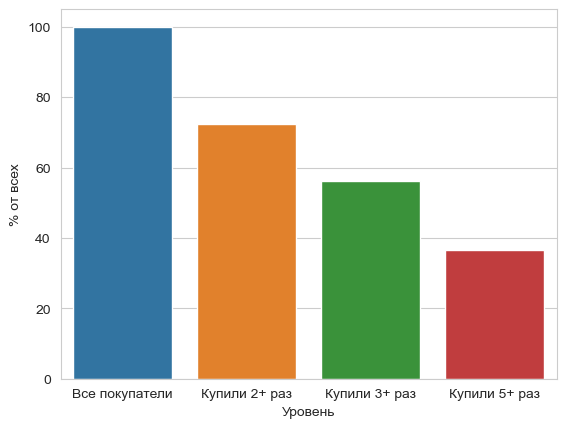

In [18]:
import seaborn as sns


sns.barplot(data= funnel, x = 'Уровень' , y = '% от всех')
plt.show()

## Воронка лояльности

Больше всего покупателей теряется после первой покупки — 27.6% не возвращаются.
Только 36.7% клиентов делают 5 и более заказов.

Вывод для бизнеса: главная точка роста — удержание новых покупателей.
Стоит сосредоточиться на онбординге после первой покупки: 
email-цепочки, персональные рекомендации, программа лояльности.

In [19]:
data_first_order = data.groupby('Customer ID')['InvoiceDate'].min()

data_first_order = data_first_order.dt.to_period('M')

data_first_order

Customer ID
12346.0    2009-12
12347.0    2010-10
12348.0    2010-09
12349.0    2010-04
12350.0    2011-02
            ...   
18283.0    2010-02
18284.0    2010-10
18285.0    2010-02
18286.0    2009-12
18287.0    2010-05
Name: InvoiceDate, Length: 5881, dtype: period[M]

In [20]:
CohortMonth = data_first_order.rename('CohortMonth').reset_index()
data_cohort = pd.merge(data, CohortMonth, on='Customer ID')
data_cohort

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12
...,...,...,...,...,...,...,...,...,...
805615,581578,22993,SET OF 4 PANTRY JELLY MOULDS,12,2011-12-09 12:16:00,1.25,12713.0,Germany,2011-12
805616,581578,22907,PACK OF 20 NAPKINS PANTRY DESIGN,12,2011-12-09 12:16:00,0.85,12713.0,Germany,2011-12
805617,581578,22908,PACK OF 20 NAPKINS RED APPLES,12,2011-12-09 12:16:00,0.85,12713.0,Germany,2011-12
805618,581578,23215,JINGLE BELL HEART ANTIQUE SILVER,12,2011-12-09 12:16:00,2.08,12713.0,Germany,2011-12


In [21]:
data_cohort['OrderMonth'] = data_cohort['InvoiceDate'].dt.to_period('M')
data_cohort

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,CohortMonth,OrderMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,2009-12
...,...,...,...,...,...,...,...,...,...,...
805615,581578,22993,SET OF 4 PANTRY JELLY MOULDS,12,2011-12-09 12:16:00,1.25,12713.0,Germany,2011-12,2011-12
805616,581578,22907,PACK OF 20 NAPKINS PANTRY DESIGN,12,2011-12-09 12:16:00,0.85,12713.0,Germany,2011-12,2011-12
805617,581578,22908,PACK OF 20 NAPKINS RED APPLES,12,2011-12-09 12:16:00,0.85,12713.0,Germany,2011-12,2011-12
805618,581578,23215,JINGLE BELL HEART ANTIQUE SILVER,12,2011-12-09 12:16:00,2.08,12713.0,Germany,2011-12,2011-12


In [22]:
data_cohort['CohortIndex'] = (data_cohort['OrderMonth'] - data_cohort['CohortMonth']).apply(lambda x: x.n)
data_cohort[['Customer ID', 'CohortMonth', 'OrderMonth', 'CohortIndex']].head(10)

,Customer ID,CohortMonth,OrderMonth,CohortIndex
0,13085.0,2009-12,2009-12,0
1,13085.0,2009-12,2009-12,0
2,13085.0,2009-12,2009-12,0
3,13085.0,2009-12,2009-12,0
4,13085.0,2009-12,2009-12,0
5,13085.0,2009-12,2009-12,0
6,13085.0,2009-12,2009-12,0
7,13085.0,2009-12,2009-12,0
8,13085.0,2009-12,2009-12,0
9,13085.0,2009-12,2009-12,0


In [23]:
cohort_data = data_cohort.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_data.head(10)

,CohortMonth,CohortIndex,Customer ID
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
5,2009-12,5,343
6,2009-12,6,360
7,2009-12,7,327
8,2009-12,8,321
9,2009-12,9,346


In [24]:
cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)
cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,359.0,270.0,233.0,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,66.0,85.0,68.0,72.0,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,376.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,43.0,47.0,57.0,65.0,46.0,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,51.0,63.0,89.0,72.0,89.0,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,22.0,41.0,41.0,46.0,46.0,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,29.0,34.0,39.0,39.0,25.0,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,29.0,37.0,40.0,33.0,30.0,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,25.0,27.0,25.0,25.0,36.0,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,21.0,20.0,25.0,30.0,29.0,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
cohort_size = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100
retention_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9,37.7,34.2,33.6,36.2,42.2,49.5,37.6,28.3,24.4,30.3,26.3,30.3,28.3,26.0,25.5,31.5,30.5,40.7,19.7
2010-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8,23.0,27.9,31.9,30.3,17.2,22.2,17.8,18.8,15.1,23.5,19.8,18.5,19.6,24.3,19.3,24.5,5.7,NaN
2010-02,100.0,23.7,22.3,29.0,24.5,19.9,19.1,28.5,25.3,27.4,11.4,12.5,15.2,17.3,12.2,19.9,16.0,16.2,14.4,22.9,22.9,16.2,5.9,NaN,NaN
2010-03,100.0,19.0,23.0,24.2,23.3,20.3,24.6,30.2,27.5,10.8,11.5,14.2,20.1,16.3,20.1,16.9,17.4,15.6,17.6,20.1,21.2,7.9,NaN,NaN,NaN
2010-04,100.0,19.4,19.4,16.3,18.4,22.4,27.6,26.2,10.5,10.9,7.5,13.9,13.9,15.6,15.6,15.6,13.9,15.0,18.0,22.4,5.8,NaN,NaN,NaN,NaN
2010-05,100.0,15.7,16.9,17.3,17.7,25.6,21.3,12.6,5.9,8.3,11.4,13.4,15.4,15.4,9.8,12.6,13.8,16.5,15.4,4.7,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.4,18.9,20.4,23.0,28.5,12.6,8.9,8.1,11.9,10.7,13.7,14.8,12.2,11.1,12.2,13.3,20.4,5.2,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.6,18.3,29.6,29.0,14.0,11.3,14.5,14.5,11.3,13.4,14.5,13.4,13.4,19.4,17.2,23.7,8.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.4,29.6,32.1,17.3,11.7,9.9,12.3,13.6,13.0,13.0,12.3,15.4,18.5,17.9,19.8,6.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


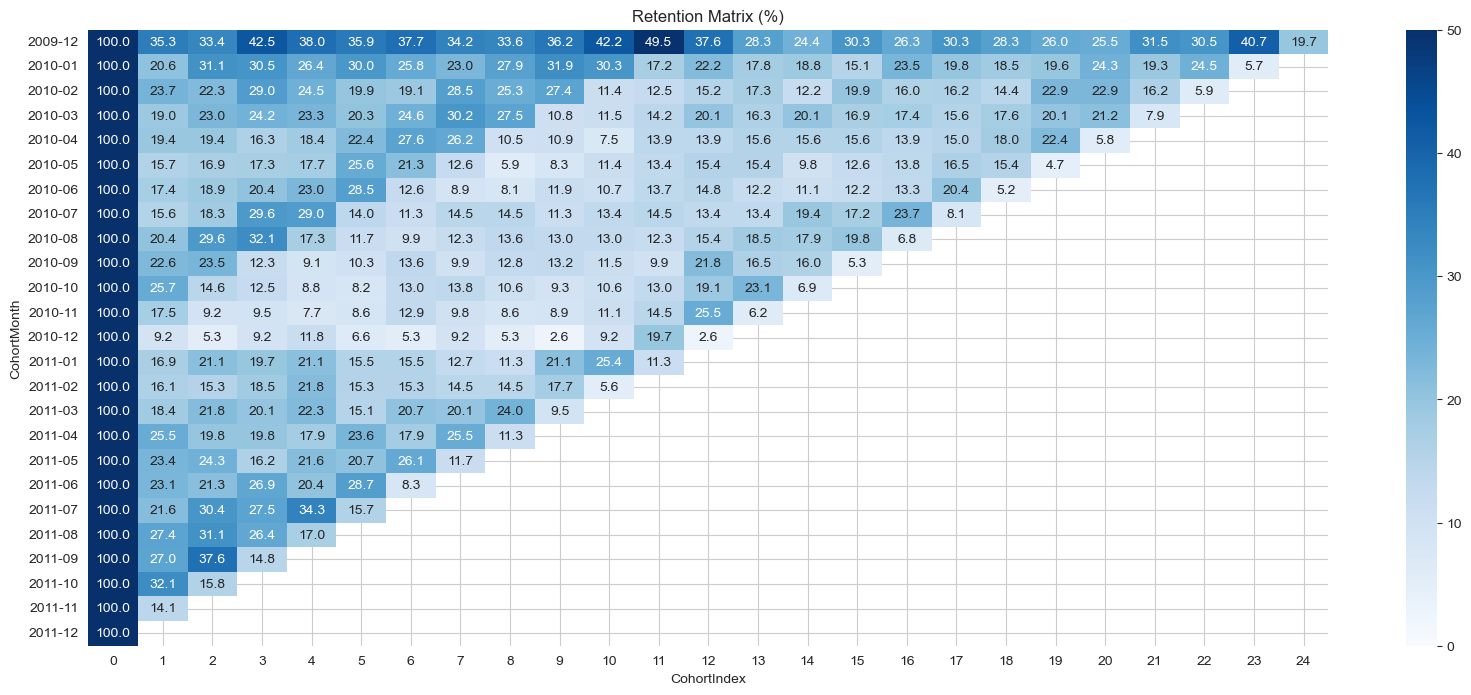

In [26]:
plt.figure(figsize=(20, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=50
)
plt.title('Retention Matrix (%)')
plt.show()

## Retention-матрица: выводы

Большинство покупателей не возвращается в следующий месяц после первой покупки — 
retention на месяц 1 составляет в среднем 15–35%.

Однако через 12 месяцев наблюдается всплеск возвращаемости — особенно 
заметно для когорты 2009-12 (49.5%). Это объясняется сезонностью: 
магазин продаёт товары для дома и подарки, покупатели возвращаются 
к тому же времени года — перед Новым годом и Рождеством.

Вывод для бизнеса: сезонные покупатели — отдельный сегмент. 
Стоит запускать email-кампании за 1-2 месяца до пикового сезона, 
чтобы вернуть тех кто покупал год назад.

## SQL-анализ через DuckDB

Дополнительный анализ данных через SQL-запросы.

In [27]:
query = """
SELECT "Customer ID", 
       SUM(Quantity * Price) as total_revenue
FROM 'online_retail_II.csv'
WHERE "Customer ID" IS NOT NULL
GROUP BY "Customer ID"
ORDER BY total_revenue DESC
LIMIT 10
"""

con.execute(query).df()

,Customer ID,total_revenue
0,18102.0,598215.22
1,14646.0,523342.07
2,14156.0,296564.69
3,14911.0,270248.53
4,17450.0,233579.39
5,13694.0,190825.52
6,17511.0,171885.98
7,12415.0,143269.29
8,16684.0,141502.25
9,15061.0,136391.48


In [31]:
query = """
SELECT 
    cohort_month,
    COUNT(DISTINCT "Customer ID") as new_customers
FROM (
    SELECT 
        "Customer ID",
        STRFTIME(MIN(InvoiceDate), '%Y-%m') as cohort_month
    FROM 'online_retail_II.csv'
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
)
GROUP BY cohort_month
ORDER BY cohort_month
"""
new_customers = con.execute(query).df()

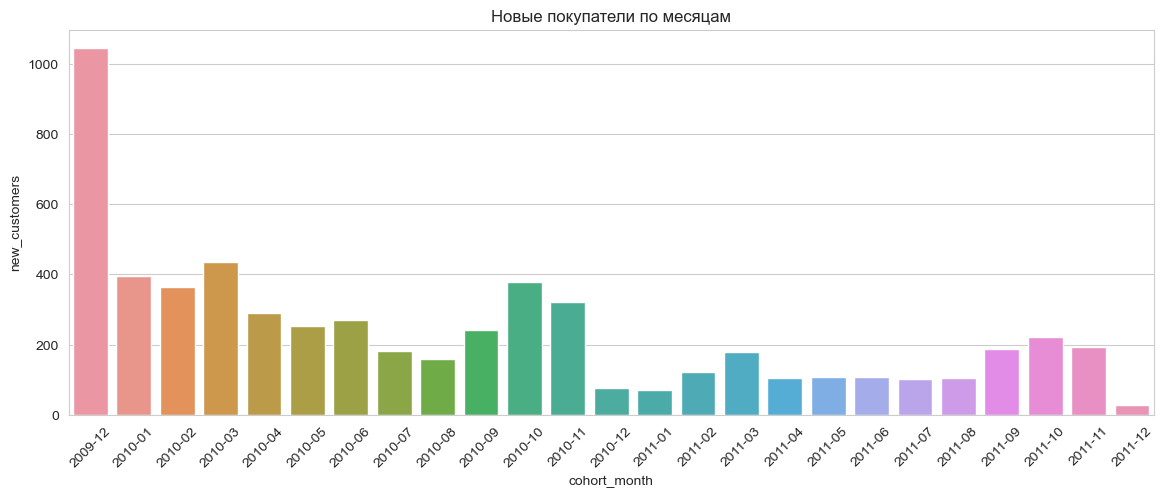

In [33]:
plt.figure(figsize=(14, 5))
sns.barplot(data=new_customers, x='cohort_month', y='new_customers')
plt.xticks(rotation=45)
plt.title('Новые покупатели по месяцам')
plt.show()

## Новые покупатели по месяцам

Количество новых покупателей снижается с каждым месяцем — 
пик пришёлся на декабрь 2009 (1045 новых клиентов).

Заметный всплеск в октябре-ноябре 2010 объясняется сезонностью — 
перед Новым годом и Рождеством магазин привлекает новую аудиторию.

Вывод для бизнеса: основной поток новых клиентов приходит в предновогодний 
сезон. Стоит усилить маркетинг в сентябре-октябре чтобы захватить 
максимум новых покупателей до пика.

In [35]:
query = """
SELECT 
    Country,
    ROUND(SUM(Quantity * Price), 2) as revenue,
    ROUND(SUM(SUM(Quantity * Price)) OVER () , 2) as total_revenue,
    ROUND(SUM(Quantity * Price) / SUM(SUM(Quantity * Price)) OVER () * 100, 2) as revenue_pct
FROM 'online_retail_II.csv'
WHERE "Customer ID" IS NOT NULL
AND Invoice NOT LIKE 'C%'
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10
"""

con.execute(query).df()

,Country,revenue,total_revenue,revenue_pct
0,United Kingdom,14723147.52,17743429.18,82.98
1,EIRE,621631.11,17743429.18,3.50
2,Netherlands,554232.34,17743429.18,3.12
3,Germany,431262.46,17743429.18,2.43
4,France,355257.47,17743429.18,2.00
5,Australia,169968.11,17743429.18,0.96
6,Spain,109178.53,17743429.18,0.62
7,Switzerland,100365.34,17743429.18,0.57
8,Sweden,91549.72,17743429.18,0.52
9,Denmark,69862.19,17743429.18,0.39


## Топ стран по выручке

Великобритания доминирует — 82.98% всей выручки. 
Это домашний рынок, он уже хорошо освоен.

Однако Ирландия (3.5%), Нидерланды (3.12%) и Германия (2.43%) 
показывают потенциал для роста — небольшая доля, но стабильный спрос.

Вывод для бизнеса: стоит инвестировать в экспансию на европейские рынки — 
особенно Ирландия и Нидерланды уже показывают интерес к продукту.